In [1]:
# Imports
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hysys import open_case
from hysys_pfr import cache_objects, run_point

# Custom Re-Implementation Of the Nested Sampler; Code is hosted @ https://github.com/Kai360-dot/NestedSampler
import nested_sampler as ns

In [2]:
CASE = r"C:\Users\kr326\Documents\Andrea_Files_MeOH_Aspen\TestAspenFile\PFR.hsc"
t0 = time.time()
case = open_case(CASE)

print(f"Case name:        {case.Name}")
print(f"Material streams: {case.Flowsheet.MaterialStreams.Count}")
print(f"Connected in      {time.time() - t0:.1f} s")

# Cache flowsheet objects
objects = cache_objects(case)
print("Objects cached OK:")
for k in objects:
    print(f"  {k}")

Case not open in HYSYS - launching (this can take a minute)...
Case name:        Case
Material streams: 2
Connected in      26.0 s
Objects cached OK:
  solver
  rin
  rout
  reactor
  components


In [3]:
# KNOBS
SMOKE_TEST = False
VOLUME = 35                     # m3, fixed reactor design
FLOW_UNIT = "kgmole/s"          # unit of the flow bounds below

# Design box; key order defines the sampler's x.  T and P are the loop's design
# variables, the six flows are the inlet hull the loop sends to the reactor.
pfr_inlet_bounds = {
    'temperature_C': [220, 280],
    'pressure_bar':  [70, 120],
    # From U_Hull, see surrogate_decomposition notebook:
    'Hydrogen': [2.115631825485868, 4.683309458965791],
    'CO': [0.03363474278468826, 0.24530105260839788],
    'CO2': [0.40419114689316316, 1.1712367732290734],
    'H2O': [0.007896525305531005, 0.010121515559163982],
    'Methanol': [0.003404552545371686, 0.012608897743876114],
    'Nitrogen': [0.056309686994445524, 0.0588813310245413]
}

# Reactor-level constraints, feasible iff residual <= 0 (see pfr_constraints).
CO_MAX = 6                     # kgmole/h net CO formed per pass

N_LIVE, N_PROP = (20, 4) if SMOKE_TEST else (100, 30)
MAX_TIME = 300 if SMOKE_TEST else 0      # a HYSYS solve is approx. 0.05 s

In [4]:
# Interface adapter: sampler vector -> HYSYS -> one flat result row
FLOW_NAMES = [k for k in pfr_inlet_bounds if k in objects["components"]]

def pfr_row(x):
    """x in pfr_inlet_bounds order -> full run_point row."""
    p = dict(zip(pfr_inlet_bounds, x))
    return run_point(objects, temperature=(p["temperature_C"], "C"),
                     pressure=(p["pressure_bar"], "bar"), volume=(VOLUME, "m3"),
                     flows=({c: p[c] for c in FLOW_NAMES}, FLOW_UNIT))

In [5]:
# Constraints on the reactor outputs, feasible iff every residual <= 0
def pfr_constraints(row):
    if not row["converged"]:
        raise RuntimeError("HYSYS did not converge")
    return [row["co_formation_kgmole_h"] - CO_MAX] # CO production rate ceiling

In [6]:
def nested_sample_unit(box, model, constraints, *, n_live, n_prop, max_time=0):
    """Nested-sample the region where constraints(model(x)) <= 0 over `box`
    ({name: [lb, ub]}, order defines x).  Returns the sampler Result and a
    DataFrame with one row per evaluation, failed ones included."""
    rows = []

    def g(x):
        row = {**dict(zip(box, x)), **model(x)}
        rows.append(row)                        # kept even if the constraints raise
        residuals = constraints(row)
        row["max_residual"] = max(residuals)    # <= 0 means feasible
        return residuals

    lb, ub = zip(*box.values())
    result = ns.NestedSampler(g, lb, ub, num_live=n_live, num_prop=n_prop, max_time=max_time).sample()
    return result, pd.DataFrame(rows)

In [7]:
t0 = time.time()
result, df = nested_sample_unit(pfr_inlet_bounds, pfr_row, pfr_constraints,
                                n_live=N_LIVE, n_prop=N_PROP, max_time=MAX_TIME)
print(result.summary())

feasible = df["max_residual"] <= 0
print(f"{len(df)} evaluations, {int(feasible.sum())} feasible, {time.time() - t0:.0f} s")
df.to_csv(f"pfr_ns{'_smoke' if SMOKE_TEST else ''}.csv", index=False)


** INITIALIZING LIVE POINTS (100)      3.39 SEC

Iterate        Contour #Feas    #Dead         Factor
----------------------------------------------------
      0     2.5367e+02    65        0     3.0000e-01
      2    -2.1301e+01   103       44     2.7528e-01
status:      NORMAL
iterations:  2
evaluations: 160 (0 failed)
wall time:   5.39 s
live:        100 points, 100 feasible, contour -2.1301e+01
dead:        44 points
discarded:   16 points
160 evaluations, 103 feasible, 5 s


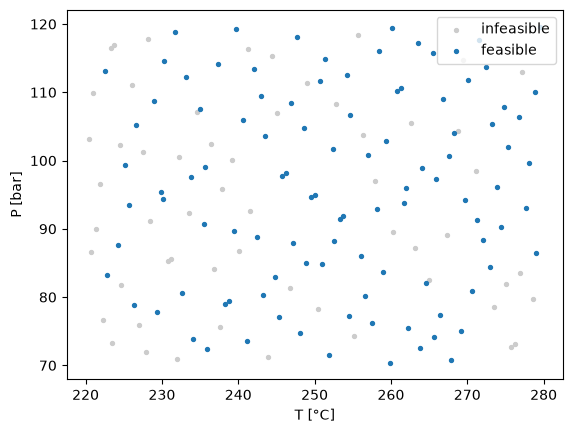

In [8]:
# Feasible points in the design plane; the six flow dimensions are projected out
fig, ax = plt.subplots()
ax.scatter(df.temperature_C[~feasible], df.pressure_bar[~feasible], s=8, color="0.8", label="infeasible")
ax.scatter(df.temperature_C[feasible], df.pressure_bar[feasible], s=8, color="C0", label="feasible")
ax.set(xlabel="T [°C]", ylabel="P [bar]")
ax.legend()